# Notebook 02: Exploratory Analysis

Chúng ta khám phá các tính chất thống kê của dữ liệu để phát hiện sự lệch khỏi **Gaussian assumption** và xác định các dấu hiệu của **heavy-tail behavior**.

---

## Objectives

1. Tính toán và diễn giải các **summary statistics** — đặc biệt là **skewness** và **excess kurtosis** — như là chỉ báo đầu tiên về **heavy tail**.
2. Kiểm định chính thức **Gaussian assumption** bằng các **normality test** (Jarque-Bera, D'Agostino-Pearson, Shapiro-Wilk).
3. Phân tích **tail behavior** qua **log-log survival plot**, **mean excess function**, và **Hill plot**.
4. Tính các chỉ số **tail risk** thực nghiệm: **VaR** và **Expected Shortfall (ES)**.
5. So sánh kết quả giữa các **dataset** để xây dựng trực giác về phổ **tail heaviness** từ **light-tail** đến **heavy-tail**.

---
## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Project modules
from src.tails.tail_metrics import (
    tail_statistics,
    tail_probability,
    tail_quantile,
    tail_conditional_expectation,
    mean_excess,
)
from src.tails.tail_plots import log_log_survival_plot, hill_plot
from src.tails.tail_index import hill_plot_data, estimate_tail_index

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

COLORS = {
    "Gaussian":     "#2166AC",
    "Student-t(5)": "#4DAC26",
    "Student-t(3)": "#F1A340",
    "Pareto(2.5)":  "#D6604D",
    "Mixed(90/10)": "#762A83",
}

### Load dữ liệu từ Notebook 01

Chúng ta đọc lại các **dataset** đã sinh và chuẩn hóa từ notebook trước. Nếu chưa chạy **Notebook 01**, hãy chạy nó trước để tạo file **Parquet**.

In [2]:
df = pd.read_parquet("../data/generated/synthetic_distributions.parquet")

datasets = {col: df[col].to_numpy() for col in df.columns}

print(f"Loaded {len(datasets)} datasets, each with {len(next(iter(datasets.values()))):,} samples.")
print("Distributions:", list(datasets.keys()))

Loaded 5 datasets, each with 5,000 samples.
Distributions: ['Gaussian', 'Student-t(5)', 'Student-t(3)', 'Pareto(2.5)', 'Mixed(90/10)']


---
## 1. Moment-Based Diagnostics

Cách đơn giản nhất để phát hiện **heavy tail** là nhìn vào các **moment** bậc cao. Trong khi **mean** và **variance** mô tả **location** và **spread**, thì **skewness** và **excess kurtosis** phản ánh hình dạng của distribution — đặc biệt là **asymmetry** và **tail heaviness**.

---

### 1.1 Kurtosis và Excess Kurtosis

**Excess kurtosis** là chỉ số trực tiếp nhất để đánh giá tail:

$$
\text{Kurt}[X] = \frac{\mu_4}{\sigma^4} - 3
$$

- $\mu_4 = \mathbb{E}[(X - \mu)^4]$: moment bậc 4
- $\sigma^2$: variance

---

### 1.2 Diễn giải

| Giá trị | Ý nghĩa |
|--------|--------|
| = 0 | Gaussian (mesokurtic) |
| > 0 | Heavy tail (leptokurtic) |
| < 0 | Light tail (platykurtic) |

Excess kurtosis dương cho thấy:
- nhiều outliers hơn Gaussian
- xác suất extreme events cao hơn

---

### 1.3 Trực giác quan trọng

Kurtosis không chỉ đo “độ nhọn” của peak như cách hiểu phổ thông, mà chủ yếu đo:

> mức độ tập trung xác suất ở tail so với Gaussian

---

### 1.4 Hạn chế của moment-based approach

Mặc dù đơn giản, cách tiếp cận này có những hạn chế quan trọng:

#### (1) Không tồn tại với heavy-tail mạnh

- Với **Pareto**:
  - Variance chỉ tồn tại khi $\alpha > 2$
  - Kurtosis chỉ tồn tại khi $\alpha > 4$

Trong nhiều trường hợp heavy-tail thực tế:
$$
\text{kurtosis} \to \infty \quad \text{hoặc không xác định}
$$

---

#### (2) Rất nhạy với outliers

- Một vài extreme values có thể làm kurtosis tăng đột biến
- Không ổn định khi sample nhỏ

---

#### (3) Không phân biệt được dạng tail

Hai distribution có thể:
- cùng kurtosis
- nhưng tail behavior hoàn toàn khác:

$$
\text{Power-law: } P(X > x) \sim x^{-\alpha}
$$

$$
\text{Gaussian: } P(X > x) \sim e^{-x^2}
$$

---

### 1.5 Kết luận

Moment-based diagnostics là bước đầu nhanh và trực quan để phát hiện dấu hiệu **heavy tail**, nhưng:

> không đủ để kết luận về bản chất tail

Trong các phần tiếp theo, chúng ta sẽ sử dụng:
- **QQ plots** để kiểm tra deviation
- **Log-log CCDF** để xác định dạng tail
- **Tail metrics (VaR, CVaR)** để lượng hóa risk

---

In [3]:
rows = []
for name, arr in datasets.items():
    ts = tail_statistics(arr, percentiles=[0.90, 0.95, 0.99, 0.999])
    rows.append({
        "Distribution":  name,
        "Mean":          round(ts["mean"], 4),
        "Std":           round(ts["std"], 4),
        "Skewness":      round(ts["skewness"], 4),
        "Exc. Kurtosis": round(ts["kurtosis"], 4),
        "Min":           round(ts["min"], 3),
        "Max":           round(ts["max"], 3),
        "Q99":           round(ts["q99"], 3),
        "Q99.9":         round(np.quantile(arr, 0.999), 3),
    })

df_stats = pd.DataFrame(rows).set_index("Distribution")
df_stats

,Mean,Std,Skewness,Exc. Kurtosis,Min,Max,Q99,Q99.9
Distribution,,,,,,,,
Gaussian,-0.0199,0.9995,0.0021,0.0362,-3.648,3.454,3.032,3.032
Student-t(5),-0.0230,1.0003,0.0291,4.3340,-8.649,8.443,4.542,4.542
Student-t(3),-0.0082,0.9357,0.0664,7.5140,-7.262,8.018,5.277,5.277
Pareto(2.5),-0.0040,0.7814,6.9658,75.4814,-0.447,12.706,9.557,9.557
Mixed(90/10),0.0000,1.0000,0.3598,5.7983,-7.306,11.547,4.043,4.043


---
## Insights from Moment-Based Diagnostics

Bảng thống kê trên cho thấy sự khác biệt rõ ràng giữa các phân phối, mặc dù tất cả đều đã được chuẩn hóa về **mean ≈ 0** và **std ≈ 1**. Điều này nhấn mạnh rằng **mean và variance không đủ để mô tả tail behavior**.

---

### 1. Gaussian làm baseline

Gaussian có:
- Skewness ≈ 0
- Excess kurtosis ≈ 0

→ Đây là phân phối **đối xứng, tail mỏng (light-tail)**.

Các quantile cực trị:
- Q99 ≈ 3.03

→ tail giảm nhanh (exponential decay), nên extreme events hiếm.

---

### 2. Student-t: đối xứng nhưng heavy tail

Cả Student-t(5) và Student-t(3) đều:
- Skewness ≈ 0 → vẫn đối xứng

Nhưng:
- Kurtosis tăng mạnh:
  - t(5): ≈ 4.33
  - t(3): ≈ 7.51

→ tail dày hơn đáng kể so với Gaussian.

Thể hiện rõ ở quantile:
- Q99:
  - Gaussian: ~3.03
  - t(5): ~4.54
  - t(3): ~5.28

→ chỉ thay đổi tail nhưng xác suất extreme tăng mạnh.

---

### 3. Pareto: tail chi phối hoàn toàn

Pareto có:
- Skewness ≈ 6.97
- Kurtosis ≈ 75.48

→ cực kỳ lệch phải và heavy tail mạnh.

Quantile:
- Q99 ≈ 9.56

→ lớn gấp nhiều lần Gaussian

Điều này cho thấy:
- distribution bị chi phối bởi một số ít giá trị cực lớn
- tail không còn là “phần nhỏ”, mà trở thành yếu tố chính

---

### 4. Mixed distribution: rủi ro bị che giấu

Mixed(90/10):
- Mean ≈ 0
- Std ≈ 1 (giống Gaussian)

Nhưng:
- Kurtosis ≈ 5.80
- Q99 ≈ 4.04

→ tail nặng hơn đáng kể

Insight quan trọng:

> Một distribution có thể trông “giống Gaussian” ở mean/std nhưng vẫn chứa tail risk lớn

---

### 5. Kết luận quan trọng

Moment-based diagnostics cho ta tín hiệu ban đầu:

- Kurtosis ↑ → tail dày hơn
- Skewness ↑ → bất đối xứng

Nhưng:

- Không phân biệt được dạng tail (power-law vs Student-t)
- Rất nhạy với outliers
- Có thể bỏ sót cấu trúc tail thực sự

---

### 6. Hệ quả

Do đó, cần kết hợp thêm:

- QQ plot → kiểm tra deviation so với Gaussian
- Log-log CCDF → xác định dạng tail (power-law hay không)
- VaR / CVaR → đo rủi ro thực tế

→ Moment chỉ là bước đầu, không phải kết luận cuối.

---

---
## 2. Normality Tests

Các **normality test** kiểm định giả thuyết:

$$
H_0: X \sim \mathcal{N}(\mu, \sigma^2)
$$

Nếu bác bỏ $H_0$, ta có bằng chứng thống kê rằng dữ liệu **không tuân theo Gaussian distribution** — một nguyên nhân phổ biến là **heavy tail**, nhưng cũng có thể do **skewness** hoặc **multi-modality**.

---

### 2.1 Các kiểm định sử dụng

Chúng ta sử dụng ba kiểm định bổ sung cho nhau:

#### (1) Jarque-Bera Test

Dựa trên **skewness** và **kurtosis**:

$$
JB = \frac{n}{6} \left( S^2 + \frac{(K - 3)^2}{4} \right)
$$

- $S$: skewness
- $K$: kurtosis
- $n$: số mẫu

Ý nghĩa:
- Kiểm tra deviation so với Gaussian thông qua moment
- Nhạy với **heavy tail (kurtosis cao)**

---

#### (2) D'Agostino-Pearson Test

Kết hợp:
- kiểm định skewness
- kiểm định kurtosis

Thống kê kiểm định:

$$
K^2 = Z_{\text{skew}}^2 + Z_{\text{kurt}}^2
$$

Ý nghĩa:
- Tổng hợp hai nguồn deviation
- Hiệu quả tốt với sample lớn

---

#### (3) Shapiro-Wilk Test

Dựa trên **order statistics**:

$$
W = \frac{\left(\sum a_i x_{(i)}\right)^2}{\sum (x_i - \bar{x})^2}
$$

- $x_{(i)}$: sorted data
- $a_i$: hệ số phụ thuộc Gaussian

Ý nghĩa:
- So sánh trực tiếp shape của data với Gaussian
- Rất nhạy với deviation ở tail

Giới hạn:
- Chỉ áp dụng tốt khi $n \le 5000$

---

### 2.2 Diễn giải kết quả

Mỗi test trả về **p-value**:

- Nếu $p$ lớn (ví dụ $p > 0.05$):
  - Không bác bỏ $H_0$
  - Data **có thể phù hợp Gaussian**

- Nếu $p$ nhỏ ($p \ll 0.05$):
  - Bác bỏ $H_0$
  - Data **không Gaussian**

---

### 2.3 Insight quan trọng

Các test này không chỉ phát hiện heavy tail, mà nói chung phát hiện:

- skewness (lệch)
- kurtosis cao (heavy tail)
- shape không Gaussian

Do đó:

> Reject normality ≠ chắc chắn heavy tail, nhưng heavy tail gần như luôn dẫn đến reject normality

---

### 2.4 Hạn chế

#### (1) Quá nhạy với sample lớn

- Với $n$ lớn:
$$
p \to 0 \quad \text{ngay cả khi deviation rất nhỏ}
$$

→ dễ “reject mọi thứ”

---

#### (2) Không cho biết *tại sao* sai

- Không phân biệt:
  - skewness
  - heavy tail
  - mixture

→ cần kết hợp với visualization

---

#### (3) Không đo mức độ tail

- Không cho biết tail dày bao nhiêu
- Không phân biệt:
$$
x^{-\alpha} \quad \text{vs} \quad e^{-x^2}
$$

---

### 2.5 Kết luận

Normality tests cung cấp:

- kiểm định thống kê chính thức
- tín hiệu rõ ràng về việc Gaussian assumption có hợp lý hay không

Tuy nhiên:

> cần kết hợp với QQ plot và CCDF để hiểu bản chất deviation

---

In [4]:
rows_test = []
for name, arr in datasets.items():
    row = {"Distribution": name}

    # Jarque-Bera
    jb_stat, jb_p = stats.jarque_bera(arr)
    row["JB stat"]  = round(jb_stat, 2)
    row["JB p-val"] = f"{jb_p:.2e}"

    # D'Agostino-Pearson
    dp_stat, dp_p = stats.normaltest(arr)
    row["DP stat"]  = round(dp_stat, 2)
    row["DP p-val"] = f"{dp_p:.2e}"

    # Shapiro-Wilk (chỉ khi n <= 5000)
    if len(arr) <= 5000:
        sw_stat, sw_p = stats.shapiro(arr)
        row["SW stat"]  = round(sw_stat, 4)
        row["SW p-val"] = f"{sw_p:.2e}"
    else:
        row["SW stat"]  = "N/A"
        row["SW p-val"] = "N/A"

    rows_test.append(row)

df_tests = pd.DataFrame(rows_test).set_index("Distribution")
df_tests

,JB stat,JB p-val,DP stat,DP p-val,SW stat,SW p-val
Distribution,,,,,,
Gaussian,0.28,8.71e-01,0.32,8.51e-01,0.9997,5.73e-01
Student-t(5),3913.92,0.00e+00,496.03,1.94e-108,0.9650,3.64e-33
Student-t(3),11766.27,0.00e+00,744.06,2.68e-162,0.9200,1.60e-45
Pareto(2.5),1227403.28,0.00e+00,6367.42,0.00e+00,0.4748,3.24e-81
Mixed(90/10),7112.20,0.00e+00,722.05,1.62e-157,0.9735,1.67e-29


---
## Insights from Normality Tests

Kết quả từ ba kiểm định (**Jarque-Bera, D'Agostino-Pearson, Shapiro-Wilk**) cho thấy sự khác biệt rõ ràng giữa Gaussian và các phân phối heavy-tail.

---

### 1. Gaussian: không bị bác bỏ

- JB p-value ≈ 0.87
- DP p-value ≈ 0.85
- SW p-value ≈ 0.57

→ Không có bằng chứng để bác bỏ $H_0$

Điều này xác nhận:
- dữ liệu Gaussian phù hợp với giả định normality
- các test hoạt động đúng như kỳ vọng

---

### 2. Student-t: deviation rõ ràng do heavy tail

#### Student-t(5):
- JB, DP p-value ≈ 0
- SW p-value ≈ $10^{-33}$

#### Student-t(3):
- JB, DP p-value ≈ 0
- SW p-value ≈ $10^{-45}$

→ Bác bỏ mạnh $H_0$

Insight:

- Skewness ≈ 0 nhưng vẫn bị reject
- Nguyên nhân chính là **kurtosis cao (heavy tail)**

So sánh:
- t(3) bị reject mạnh hơn t(5)
→ tail càng dày → deviation càng lớn

---

### 3. Pareto: lệch hoàn toàn khỏi Gaussian

- Tất cả p-value ≈ 0
- JB, DP statistic cực lớn

→ Gaussian assumption hoàn toàn không phù hợp

Nguyên nhân:
- Skewness rất lớn
- Tail dạng power-law

→ deviation không chỉ ở tail mà ở toàn bộ distribution

---

### 4. Mixed distribution: “trông giống Gaussian nhưng vẫn bị reject”

- Mean, std gần Gaussian
- Nhưng:
  - JB, DP p-value ≈ 0
  - SW p-value ≈ $10^{-29}$

→ Bị bác bỏ mạnh

Insight quan trọng:

> Một distribution có thể có mean/std giống Gaussian nhưng vẫn không Gaussian do tail khác

Nguyên nhân:
- mixture tạo ra rare extreme events
- kurtosis tăng → test detect được

---

### 5. So sánh ba kiểm định

| Test | Nhạy với |
|------|--------|
| Jarque-Bera | skewness + kurtosis |
| D’Agostino-Pearson | combined deviation |
| Shapiro-Wilk | shape tổng thể (đặc biệt tail) |

Quan sát:

- JB và DP cho statistic rất lớn khi kurtosis cao
- Shapiro-Wilk cho p-value cực nhỏ → nhạy nhất với tail deviation

---

### 6. Kết luận

Kết quả cho thấy:

- Gaussian → pass tất cả test
- Student-t → fail do heavy tail
- Pareto → fail hoàn toàn
- Mixed → fail dù nhìn “gần Gaussian”

Insight cốt lõi:

> Normality tests rất nhạy với tail behavior và có thể phát hiện heavy tail ngay cả khi mean và variance không thay đổi

---

### 7. Hệ quả

- Reject normality không chỉ do skewness
- Heavy tail là nguyên nhân phổ biến nhất trong dữ liệu thực

Tuy nhiên:

> Các test này chỉ cho biết “không Gaussian”, không cho biết “tail thuộc loại gì”

→ cần kết hợp với:
- QQ plot
- Log-log CCDF

---

---
## 3. Tail Behavior Analysis

Các **normality test** chỉ cho biết dữ liệu có **Gaussian** hay không. Để hiểu *mức độ* và *dạng* của **heavy tail**, chúng ta cần các công cụ phân tích **tail** chuyên biệt hơn.

---

### 3.1 Log-Log Survival Plot

Xét **survival function** (CCDF):

$$
\bar{F}(x) = P(X > x)
$$

Trên thang **log-log**, nếu tail có dạng **power-law**:

$$
P(X > x) \sim x^{-\alpha}
$$

thì:

$$
\log P(X > x) = -\alpha \log x
$$

→ biểu diễn thành **đường thẳng** với slope $-\alpha$

---

### Diễn giải

- **Đường thẳng** → tail dạng power-law (Pareto-like)
- **Đường cong xuống mạnh** → light tail (Gaussian)
- **Gần thẳng ở tail nhưng cong ở body** → heavy tail nhưng không pure power-law (ví dụ Student-t)

---

### Tail Index $\alpha$

Hệ số góc của đường thẳng:

$$
\text{slope} = -\alpha
$$

→ cho biết tốc độ decay của tail:

| $\alpha$ | Ý nghĩa |
|---------|--------|
| nhỏ | tail rất dày (extreme events nhiều) |
| lớn | tail mỏng hơn |

---

### Trực giác quan trọng

So sánh hai dạng decay:

$$
\text{Power-law: } P(X > x) \sim x^{-\alpha}
$$

$$
\text{Gaussian: } P(X > x) \sim e^{-x^2}
$$

- Power-law giảm chậm → extreme events vẫn đáng kể
- Gaussian giảm rất nhanh → extreme gần như không xảy ra

---

### Hạn chế

- Cần đủ dữ liệu ở tail (ít điểm → noisy)
- Dễ nhầm nếu nhìn cả body (cần focus vào tail region)
- Không phải mọi heavy-tail đều là power-law

---

### 3.6 Kết luận

Log-log survival plot là công cụ trực quan mạnh để:

- phát hiện **power-law behavior**
- ước lượng **tail index $\alpha$**
- phân biệt **heavy tail vs light tail**

---

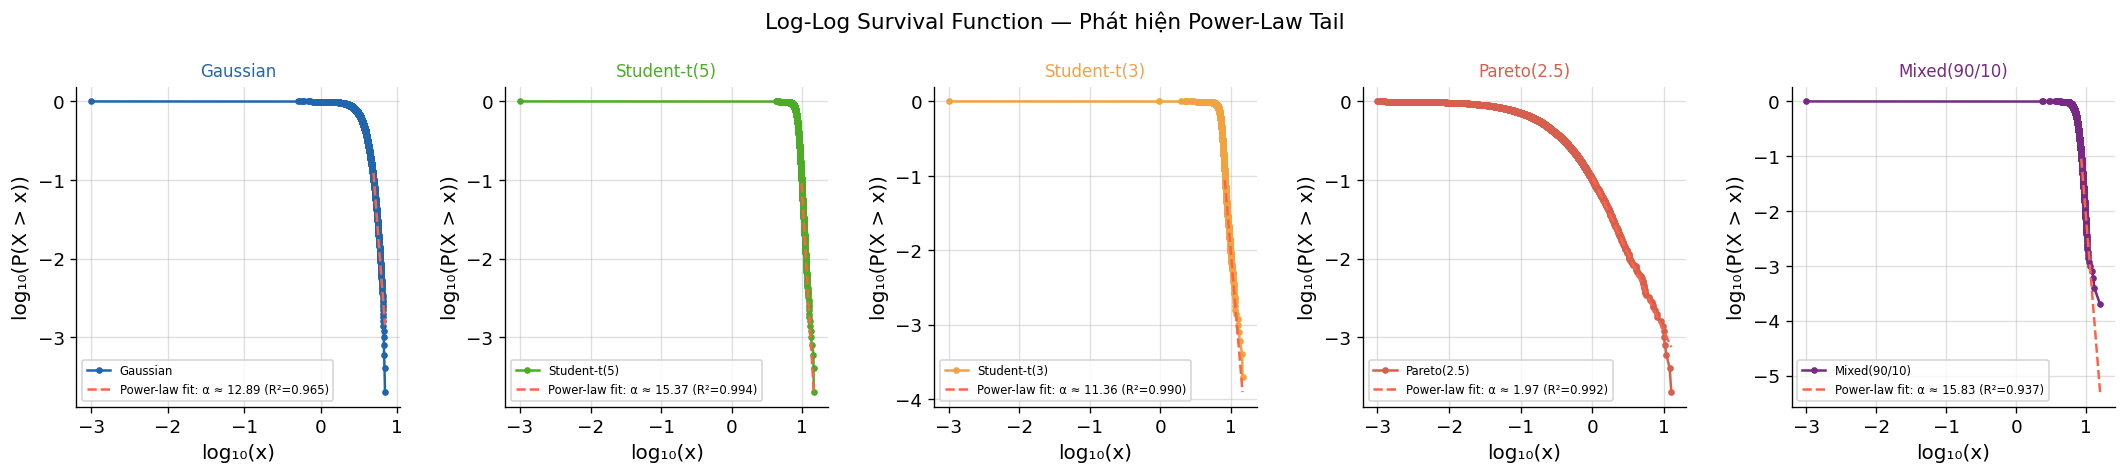

In [5]:
fig, axes = plt.subplots(1, len(datasets), figsize=(18, 4), sharey=False)

for ax, (name, arr) in zip(axes, datasets.items()):
    # Dịch để đảm bảo dương hoàn toàn
    x_pos = arr - arr.min() + 1e-3
    log_log_survival_plot(
        x_pos, ax=ax,
        label=name,
        color=COLORS[name],
        fit_power_law=True,
        tail_fraction=0.10,
    )
    ax.set_title(name, fontsize=10, color=COLORS[name])
    ax.legend(fontsize=7)

fig.suptitle("Log-Log Survival Function — Phát hiện Power-Law Tail", fontsize=13)
plt.tight_layout()
plt.show()

Biểu đồ log-log CCDF cho thấy rõ sự khác biệt bản chất giữa các loại tail, vượt xa những gì moment hay normality test có thể cung cấp.

#### Gaussian: light tail (exponential decay)

- Đường cong **rơi rất nhanh và cong mạnh xuống**
- Không có đoạn tuyến tính ở tail

→ xác nhận:

$$
P(X > x) \sim e^{-x^2}
$$

Gaussian **không có power-law tail**

---

#### Student-t: heavy tail nhưng không thuần power-law

- Ở vùng tail, đường bắt đầu **gần tuyến tính**
- Nhưng không hoàn toàn thẳng trên toàn miền

→ cho thấy:

- Tail có dạng gần power-law khi $x$ lớn
- Nhưng vẫn bị ảnh hưởng bởi phần “body” của distribution

Insight:

> Student-t có heavy tail, nhưng không phải pure power-law như Pareto

---

#### Pareto: power-law rõ ràng

- Đường gần như **thẳng hoàn toàn trên log-log scale**
- Fit tuyến tính rất tốt ($R^2 \approx 1$)

→ xác nhận:

$$
P(X > x) \sim x^{-\alpha}
$$

- $\alpha \approx 2$ (gần với tham số sinh dữ liệu)

Insight:

> Đây là trường hợp duy nhất có **power-law tail thực sự**

---

#### Mixed (90/10): tail “giả power-law”

- Phần tail có thể **trông gần tuyến tính trong một khoảng nhỏ**
- Nhưng không ổn định trên toàn miền

→ do:
- mixture giữa Gaussian (light tail) và component variance lớn

Insight:

> Mixture có thể **giả vờ giống power-law trong một đoạn**, nhưng không phải bản chất

---

### So sánh tổng thể

| Distribution | Shape trên log-log | Tail type |
|-------------|------------------|----------|
| Gaussian | cong mạnh | exponential (light tail) |
| Student-t | gần thẳng ở tail | heavy tail |
| Pareto | thẳng rõ ràng | power-law |
| Mixed | bán tuyến tính | hybrid |

---

### Insight quan trọng

- **Đường thẳng trên log-log là dấu hiệu duy nhất đáng tin của power-law**
- Heavy tail ≠ power-law (Student-t là ví dụ điển hình)
- Mixture có thể gây **false power-law impression**

---

### Kết luận

Log-log survival plot cho phép:

- phân biệt rõ:
  - exponential vs power-law
- xác định:
  - tail structure thực sự
- phát hiện:
  - các trường hợp “giả heavy-tail”

→ Đây là công cụ quan trọng nhất khi phân tích **extreme risk**

---

### 3.2 Mean Excess Function (MEF)

**Mean Excess Function** (MEF), còn gọi là **Mean Residual Life**, được định nghĩa:

$$
e(u) = \mathbb{E}[X - u \mid X > u]
$$

Đây là giá trị kỳ vọng của phần **vượt ngưỡng** $u$, tức là: nếu đã vượt qua $u$, thì trung bình sẽ vượt thêm bao nhiêu.

---

### 3.2.1 Trực giác

MEF trả lời câu hỏi:

> Nếu đã xảy ra một sự kiện lớn hơn $u$, thì nó còn “lớn thêm” bao nhiêu nữa?

---

### 3.2.2 Hành vi theo từng loại phân phối

#### Gaussian (light tail)

- $e(u)$ **giảm** khi $u$ tăng
- Tail giảm rất nhanh

→ khi đã vào tail:
- giá trị vượt thêm không đáng kể

Insight:

> Extreme events trong Gaussian bị “giới hạn”, không thể quá lớn

---

#### Exponential

- $e(u)$ là **hằng số**

$$
e(u) = \text{const}
$$

→ không phụ thuộc vào $u$

Insight:

> Không có “memory”: đã lớn rồi thì vẫn chỉ lớn thêm như cũ

---

#### Heavy-tail (power-law, Pareto)

- $e(u)$ **tăng tuyến tính** theo $u$

$$
e(u) \propto u
$$

→ càng đi sâu vào tail:
- giá trị vượt thêm càng lớn

Insight:

> Extreme events sinh ra **extreme hơn nữa**

---

### 3.2.3 Ý nghĩa quan trọng

MEF là công cụ mạnh để phân biệt:

| Behavior | Loại tail |
|--------|----------|
| giảm | light tail |
| hằng | exponential |
| tăng | heavy tail |

---

### 3.2.4 Liên hệ với EVT (POT method)

Trong **Peaks Over Threshold (POT)**:

- chọn ngưỡng $u$ sao cho:
  - $e(u)$ bắt đầu có xu hướng **tuyến tính**

→ khi đó:
- tail có thể được mô hình bằng **Generalized Pareto Distribution (GPD)**

---

### 3.2.5 Insight thực nghiệm

Trong dữ liệu:

- Gaussian → MEF cong xuống
- Student-t → gần tuyến tính ở tail
- Pareto → tuyến tính rõ ràng
- Mixed → có thể “gãy khúc” (regime change)

---

### 3.2.6 Hạn chế

- Nhạy với sample nhỏ ở tail
- Dễ noisy khi $u$ lớn
- Cần kết hợp với CCDF và QQ plot để xác nhận

---

### 3.2.7 Kết luận

Mean Excess Function cung cấp một góc nhìn bổ sung:

- không chỉ xem tail “dày hay mỏng”
- mà xem **tail phát triển như thế nào khi threshold tăng**

→ đặc biệt quan trọng trong **extreme value modeling**

---

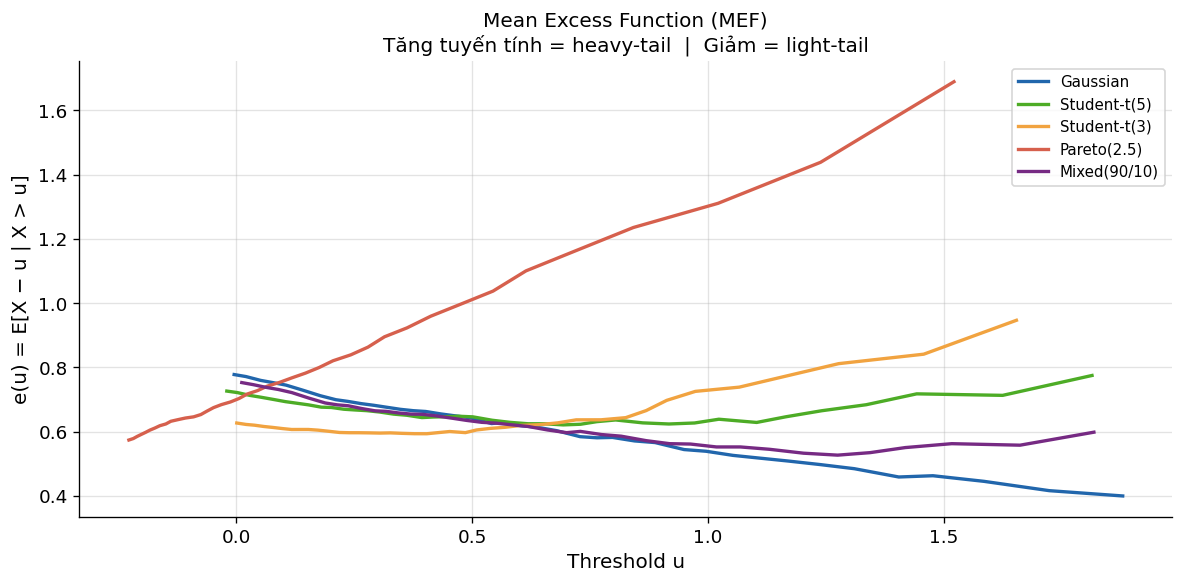

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, arr in datasets.items():
    # Tính MEF trên lưới threshold từ Q50 đến Q97
    u_grid = np.quantile(arr, np.linspace(0.50, 0.97, 40))
    mef_vals = []
    valid_u  = []
    for u in u_grid:
        try:
            mef_vals.append(mean_excess(arr, float(u)))
            valid_u.append(float(u))
        except ValueError:
            continue
    ax.plot(valid_u, mef_vals, lw=2, color=COLORS[name], label=name)

ax.set_xlabel("Threshold u", fontsize=12)
ax.set_ylabel("e(u) = E[X − u | X > u]", fontsize=12)
ax.set_title("Mean Excess Function (MEF)\nTăng tuyến tính = heavy-tail  |  Giảm = light-tail", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

### Insights from Mean Excess Function (MEF)

Biểu đồ MEF cung cấp một góc nhìn rất rõ ràng về cách **tail phát triển khi threshold $u$ tăng**.

---

#### Gaussian: tail mỏng (light tail)

- $e(u)$ **giảm đều** khi $u$ tăng
- Đường cong đi xuống rõ ràng

→ Khi đã vượt ngưỡng cao:
- phần vượt thêm ngày càng nhỏ

Insight:

> Extreme events trong Gaussian bị “kéo về”, không thể tăng mạnh

---

#### Student-t: heavy tail mức vừa

- $e(u)$ gần như **phẳng ở vùng đầu**
- Sau đó bắt đầu **tăng nhẹ**

→ cho thấy:
- tail nặng hơn Gaussian
- nhưng chưa phải power-law thuần

So sánh:
- t(3) tăng rõ hơn t(5)
→ df nhỏ hơn → tail dày hơn

---

#### Pareto: power-law tail rõ ràng

- $e(u)$ **tăng gần tuyến tính theo $u$**
- Độ dốc lớn và ổn định

→ xác nhận:

$$
e(u) \propto u
$$

Insight:

> Càng đi sâu vào tail, giá trị extreme càng “bùng nổ”

---

#### Mixed (90/10): hành vi lai (hybrid)

- Ban đầu: giống Gaussian (giảm nhẹ)
- Sau đó: bắt đầu **tăng lại**

→ phản ánh:
- mixture của:
  - component Gaussian (light tail)
  - component variance lớn (heavy tail)

Insight:

> Tail behavior không đồng nhất — phụ thuộc vào regime

---

### So sánh tổng thể

| Distribution | Shape của $e(u)$ | Kết luận |
|-------------|----------------|----------|
| Gaussian | giảm | light tail |
| Student-t | gần phẳng → tăng nhẹ | heavy tail |
| Pareto | tăng tuyến tính | power-law |
| Mixed | giảm → tăng | hybrid |

---

### Insight quan trọng

- MEF giúp phân biệt:
  - tail “bị giới hạn” (Gaussian)
  - tail “mở rộng” (Pareto)

- Không chỉ nói tail dày hay mỏng, mà còn:

> tail phát triển nhanh hay chậm khi threshold tăng

---

###  Kết luận

Kết hợp với các phần trước:

- **QQ plot** → phát hiện deviation
- **CCDF** → xác định dạng tail
- **MEF** → hiểu dynamics của tail

→ MEF là công cụ quan trọng để:
- chọn threshold trong EVT
- xác nhận power-law behavior

---

---
### 3.3 Hill Plot

**Hill estimator** là phương pháp kinh điển để ước lượng **tail index** $\alpha$ của phân phối có **power-law tail**.

Giả sử $X_{(1)} \le \cdots \le X_{(n)}$ là dữ liệu đã sắp xếp tăng dần, khi đó:

$$
\hat{\alpha}(k) = \left(\frac{1}{k} \sum_{i=1}^{k} \log \frac{X_{(n-i+1)}}{X_{(n-k)}}\right)^{-1}
$$

- $k$: số lượng điểm lớn nhất (tail sample) được sử dụng
- $X_{(n-i+1)}$: các order statistic lớn nhất
- $X_{(n-k)}$: threshold (mốc bắt đầu tail)

---

### 3.3.1 Trực giác

Hill estimator chỉ sử dụng **top $k$ giá trị lớn nhất** để ước lượng tail.

Ý tưởng:

> Nếu tail tuân theo power-law, thì phần đuôi sẽ “tự giống nhau” (self-similar)

→ có thể ước lượng $\alpha$ chỉ từ extreme values

---

### 3.3.2 Hill Plot

**Hill plot** vẽ:

$$
k \;\; \text{vs} \;\; \hat{\alpha}(k)
$$

Mục tiêu:

- tìm **stable region**
- vùng mà $\hat{\alpha}(k)$ gần như **không đổi theo $k$**

---

### 3.3.3 Diễn giải

- Nếu tồn tại đoạn phẳng:
  → có power-law tail
  → $\alpha$ ≈ giá trị trong đoạn đó

- Nếu không có đoạn ổn định:
  → không phải power-law thuần
  → hoặc dữ liệu chưa đủ sâu vào tail

---

### 3.3.4 Trade-off quan trọng (chọn k)

Việc chọn $k$ là critical:

- $k$ nhỏ:
  - variance cao (noise)
  - estimate không ổn định

- $k$ lớn:
  - bias cao (lẫn body vào tail)
  - phá vỡ giả định power-law

→ Hill plot giúp cân bằng bias–variance

---

### 3.3.5 Ý nghĩa của $\alpha$

| $\alpha$ | Ý nghĩa |
|---------|--------|
| nhỏ | tail rất dày |
| lớn | tail mỏng hơn |

Liên hệ với moment:

- $\alpha \le 2$ → variance không tồn tại
- $\alpha \le 1$ → mean không tồn tại

---

### 3.3.6 Liên hệ với các phân phối

- **Pareto**:
  - Hill plot có **plateau rõ ràng**
  - estimate $\alpha$ ổn định

- **Student-t**:
  - có thể thấy plateau ở tail sâu
  - nhưng kém ổn định hơn

- **Gaussian**:
  - không có plateau
  - $\hat{\alpha}$ tăng không ổn định

- **Mixed**:
  - có thể xuất hiện “fake plateau”
  - cần kiểm tra bằng CCDF / MEF

---

### 3.3.7 Hạn chế

- Chỉ áp dụng tốt khi:
  - tail thực sự là power-law
- Nhạy với:
  - outliers
  - sample size nhỏ
- Dễ bị:
  - chọn sai $k$
  - over-interpretation

---

### 3.3.8 Kết luận

Hill plot là công cụ quan trọng để:

- ước lượng **tail index $\alpha$**
- kiểm tra **power-law assumption**
- hỗ trợ chọn threshold trong EVT

Tuy nhiên:

> cần kết hợp với CCDF và MEF để tránh kết luận sai

---

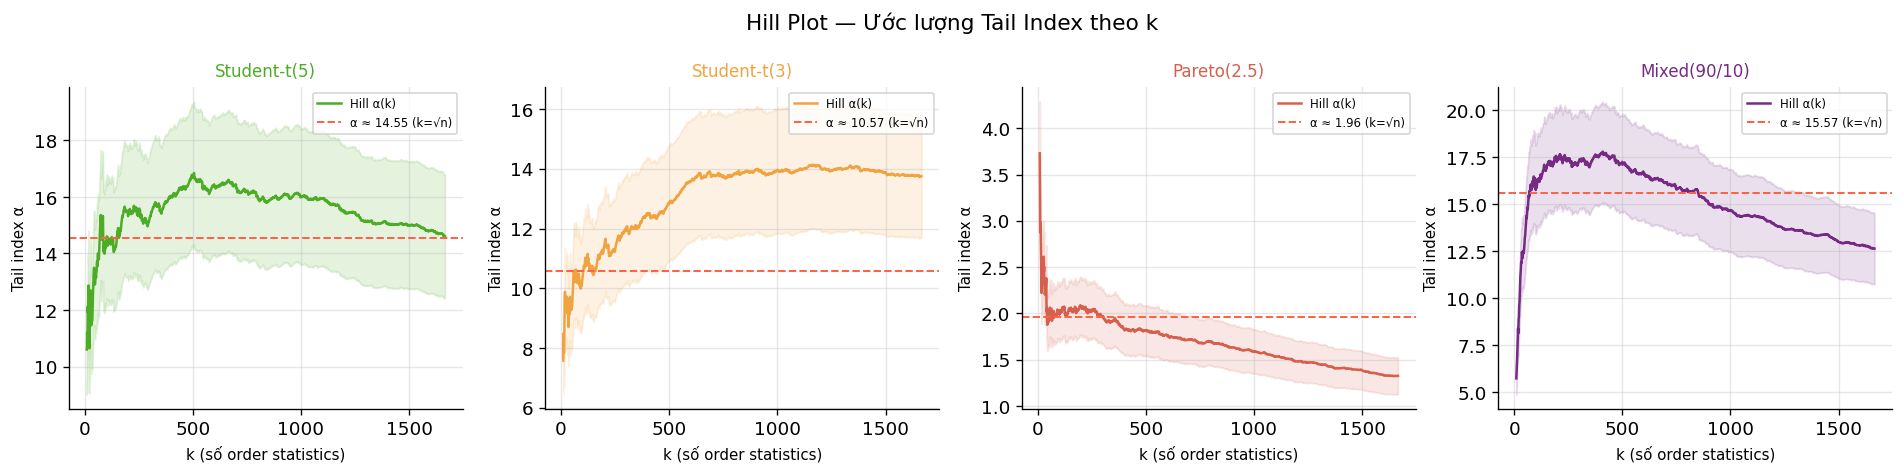

In [7]:
# Hill plot chỉ có nghĩa với strictly positive data và heavy-tail distributions
heavy_tail_sets = {
    k: v for k, v in datasets.items()
    if k != "Gaussian"   # Gaussian không có power-law tail
}

fig, axes = plt.subplots(1, len(heavy_tail_sets), figsize=(16, 4), sharey=False)

for ax, (name, arr) in zip(axes, heavy_tail_sets.items()):
    # Hill estimator yêu cầu strictly positive data
    x_pos = arr - arr.min() + 1e-3
    n     = len(x_pos)
    k_values, alpha_values = hill_plot_data(
        x_pos, k_min=10, k_max=n // 3
    )
    ax.plot(k_values, alpha_values, color=COLORS[name], lw=1.5, label="Hill α(k)")
    ax.fill_between(k_values,
                    alpha_values * 0.85,
                    alpha_values * 1.15,
                    alpha=0.15, color=COLORS[name])
    # Đánh dấu ước lượng tại k = sqrt(n)
    k_ref = int(np.sqrt(n))
    try:
        alpha_ref = estimate_tail_index(x_pos, k=k_ref)
        ax.axhline(alpha_ref, color="tomato", lw=1.2, ls="--",
                   label=f"α ≈ {alpha_ref:.2f} (k=√n)")
    except Exception:
        pass
    ax.set_title(name, fontsize=10, color=COLORS[name])
    ax.set_xlabel("k (số order statistics)", fontsize=9)
    ax.set_ylabel("Tail index α", fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle("Hill Plot — Ước lượng Tail Index theo k", fontsize=13)
plt.tight_layout()
plt.show()

---
###  Insights from Hill Plot

Hill plot cho thấy cách **tail index $\alpha$ thay đổi theo $k$**, từ đó đánh giá xem tail có thực sự là power-law hay không.

---

#### Student-t(5): plateau tương đối rõ

- $\hat{\alpha}(k)$ tăng nhanh ban đầu, sau đó **ổn định trong một khoảng $k$**
- Sau vùng plateau, $\alpha$ giảm dần (do bias khi $k$ quá lớn)

Insight:

> Có dấu hiệu heavy tail, nhưng plateau không hoàn toàn ổn định → không phải power-law thuần

---

#### Student-t(3): plateau rõ hơn

- $\hat{\alpha}(k)$ ổn định hơn trong vùng trung gian
- Giá trị $\alpha$ thấp hơn so với t(5)

→ phù hợp với việc tail dày hơn

Insight:

> Tail behavior gần power-law hơn t(5), nhưng vẫn không hoàn toàn ổn định

---

#### Pareto(2.5): plateau rõ ràng nhất

- $\hat{\alpha}(k)$ nhanh chóng hội tụ về ~2
- Có vùng ổn định tương đối rõ

→ xác nhận:

$$
\alpha \approx 2
$$

Insight:

> Đây là trường hợp duy nhất có **power-law tail thực sự**

---

#### Mixed(90/10): plateau “giả”

- $\hat{\alpha}(k)$ ban đầu có vẻ ổn định
- Nhưng sau đó **trôi dần theo $k$**

→ không có vùng plateau rõ ràng

Insight:

> Mixture có thể tạo illusion của power-law, nhưng không bền vững

---

### So sánh tổng thể

| Distribution | Hill behavior | Kết luận |
|-------------|--------------|----------|
| Student-t(5) | plateau yếu | heavy tail |
| Student-t(3) | plateau rõ hơn | heavy tail mạnh |
| Pareto | plateau rõ | power-law |
| Mixed | không ổn định | không phải power-law |

---

### Insight quan trọng

- Plateau ổn định là dấu hiệu mạnh của power-law
- Heavy tail không đồng nghĩa với power-law
- Mixture có thể gây **false plateau**

---

### Kết luận

Hill plot cho phép:

- ước lượng **tail index $\alpha$**
- kiểm tra tính ổn định của tail
- phân biệt:
  - power-law thật
  - heavy tail “giả”

Tuy nhiên:

> cần kết hợp với CCDF và MEF để xác nhận kết luận

---

---
## 4. Tail Risk Metrics

Chúng ta tính hai **risk metric** quan trọng nhất trong **financial risk management** và **insurance**: **Value at Risk (VaR)** và **Expected Shortfall (ES / CVaR)**. Hai metric này trực tiếp lượng hóa **tail risk** — điều mà moment hay normality test không làm được.

---

### 4.1 Value at Risk (VaR)

**Value at Risk** ở mức $p$ được định nghĩa là **quantile**:

$$
\text{VaR}_p = Q_p = F^{-1}(p)
$$

tương đương:

$$
P(X > \text{VaR}_p) = 1 - p
$$

---

#### Diễn giải

- $\text{VaR}_{0.95}$: mức thua lỗ mà chỉ **5\% trường hợp xấu nhất** vượt qua
- Đây là **ngưỡng (threshold)**, không phải mức độ tail

---

#### Trực giác

> VaR trả lời: “Trong điều kiện bình thường, ta có thể lỗ tối đa bao nhiêu?”

---

#### Hạn chế

- Không nói gì về mức độ thiệt hại khi vượt VaR
- Không phân biệt:
$$
\text{lỗ } 6\% \quad \text{vs} \quad \text{lỗ } 50\%
$$

→ đặc biệt nguy hiểm với **heavy-tail**

---

### 4.2 Expected Shortfall (ES / CVaR)

**Expected Shortfall** được định nghĩa:

$$
\text{ES}_p = \mathbb{E}[X \mid X > \text{VaR}_p]
$$

---

#### Diễn giải

- Là **trung bình của các thua lỗ trong vùng tệ nhất**
- Tập trung vào **tail thực sự**, không chỉ threshold

---

#### Trực giác

> ES trả lời: “Khi mọi thứ thực sự xấu đi, ta sẽ lỗ trung bình bao nhiêu?”

---

### 4.3 So sánh VaR vs ES

| Metric | Đo cái gì | Nhìn tail |
|--------|----------|----------|
| VaR | threshold | không |
| ES | tail average | có |

---

### 4.4 Hành vi theo distribution

#### Gaussian

- Tail mỏng
- VaR và ES gần nhau

$$
\text{ES} \approx \text{VaR}
$$

---

#### Heavy-tail (Student-t, Pareto)

- Tail dày
- ES lớn hơn VaR đáng kể

$$
\text{ES} \gg \text{VaR}
$$

→ gap này phản ánh **tail risk thực sự**

---

### 4.5 Insight quan trọng

- VaR chỉ nhìn **biên (edge)**
- ES nhìn **toàn bộ tail**

Do đó:

> ES nhạy với tail behavior hơn và là metric phù hợp cho heavy-tail

---

### 4.6 Liên hệ với EVT

Trong **Extreme Value Theory**:

- VaR → quantile của tail
- ES → phụ thuộc trực tiếp vào tail distribution

Ví dụ với Pareto:

$$
\text{ES}_p \propto \frac{\alpha}{\alpha - 1} \cdot \text{VaR}_p
$$

→ khi $\alpha$ nhỏ:
- ES tăng rất nhanh
- tail risk “bùng nổ”

---

### 4.7 Kết luận

- VaR đơn giản và dễ hiểu, nhưng thiếu thông tin
- ES phản ánh đúng bản chất tail risk

Trong thực tế:

> ES được ưu tiên trong các framework hiện đại (Basel III, Solvency II)

---

### 4.8 Liên hệ thực nghiệm

Trong dữ liệu của chúng ta:

- Gaussian → VaR và ES gần nhau
- Student-t → ES lớn hơn đáng kể
- Pareto → ES vượt xa VaR
- Mixed → ES phát hiện tail risk bị “che giấu”

---

In [8]:
confidence_levels = [0.90, 0.95, 0.99]
rows_risk = []

for name, arr in datasets.items():
    row = {"Distribution": name}
    for p in confidence_levels:
        var = tail_quantile(arr, 1.0 - p, tail="right")
        es  = tail_conditional_expectation(arr, p, tail="right")
        row[f"VaR {int(p*100)}%"] = round(var, 3)
        row[f"ES  {int(p*100)}%"] = round(es, 3)
    rows_risk.append(row)

df_risk = pd.DataFrame(rows_risk).set_index("Distribution")
df_risk

,VaR 90%,ES 90%,VaR 95%,ES 95%,VaR 99%,ES 99%
Distribution,,,,,,
Gaussian,1.249,1.745,1.616,2.066,2.375,2.686
Student-t(5),1.119,1.746,1.507,2.217,2.563,3.493
Student-t(3),0.926,1.626,1.315,2.154,2.533,3.698
Pareto(2.5),0.558,1.606,1.089,2.439,2.843,5.572
Mixed(90/10),1.215,1.747,1.567,2.124,2.318,3.165


---
### Insights from Tail Risk Metrics

Kết quả VaR và ES cho thấy rõ sự khác biệt về **tail risk**, ngay cả khi các distribution đã được chuẩn hóa về mean và variance.

---

#### Gaussian: baseline (light tail)

- VaR tăng đều theo mức $p$
- ES chỉ lớn hơn VaR một chút:

$$
\text{ES}_{99} \approx 2.69 \quad \text{vs} \quad \text{VaR}_{99} \approx 2.38
$$

→ tail mỏng, rủi ro extreme bị giới hạn

---

#### Student-t: tail dày hơn nhưng vẫn đối xứng

##### Student-t(5):
- VaR tăng nhẹ so với Gaussian
- ES tăng rõ hơn:

$$
\text{ES}_{99} \approx 3.49
$$

##### Student-t(3):
- VaR không quá lớn
- Nhưng ES tăng mạnh:

$$
\text{ES}_{99} \approx 3.70
$$

Insight:

> Tail dày không làm VaR tăng nhiều, nhưng làm ES tăng mạnh

---

#### Pareto: tail chi phối hoàn toàn

- VaR không quá lớn:
$$
\text{VaR}_{99} \approx 2.84
$$

- Nhưng ES cực lớn:
$$
\text{ES}_{99} \approx 5.57
$$

→ gap rất lớn giữa VaR và ES

Insight:

> VaR đánh giá thấp rủi ro trong power-law tail

---

#### Mixed (90/10): rủi ro bị “che giấu”

- VaR gần giống Gaussian:
$$
\text{VaR}_{99} \approx 2.32
$$

- Nhưng ES cao hơn đáng kể:
$$
\text{ES}_{99} \approx 3.17
$$

Insight:

> Mean và VaR có thể “đánh lừa”, nhưng ES vẫn phát hiện tail risk

---

###  So sánh tổng thể

| Distribution | VaR | ES | Nhận xét |
|-------------|-----|----|----------|
| Gaussian | thấp | gần VaR | light tail |
| Student-t | trung bình | cao hơn | heavy tail |
| Pareto | không quá lớn | rất cao | power-law |
| Mixed | giống Gaussian | cao hơn | hidden risk |

---

### Insight quan trọng

- VaR chỉ đo **ngưỡng**
- ES đo **mức độ thiệt hại thực sự trong tail**

Do đó:

$$
\text{Heavy tail} \Rightarrow \text{ES} - \text{VaR} \uparrow
$$

---

### Kết luận

- Gaussian → VaR và ES gần nhau
- Student-t → ES phản ánh tail rõ hơn
- Pareto → VaR thất bại, ES mới phản ánh đúng risk
- Mixed → ES phát hiện rủi ro bị ẩn

> ES là metric quan trọng nhất để đánh giá tail risk trong thực tế

---

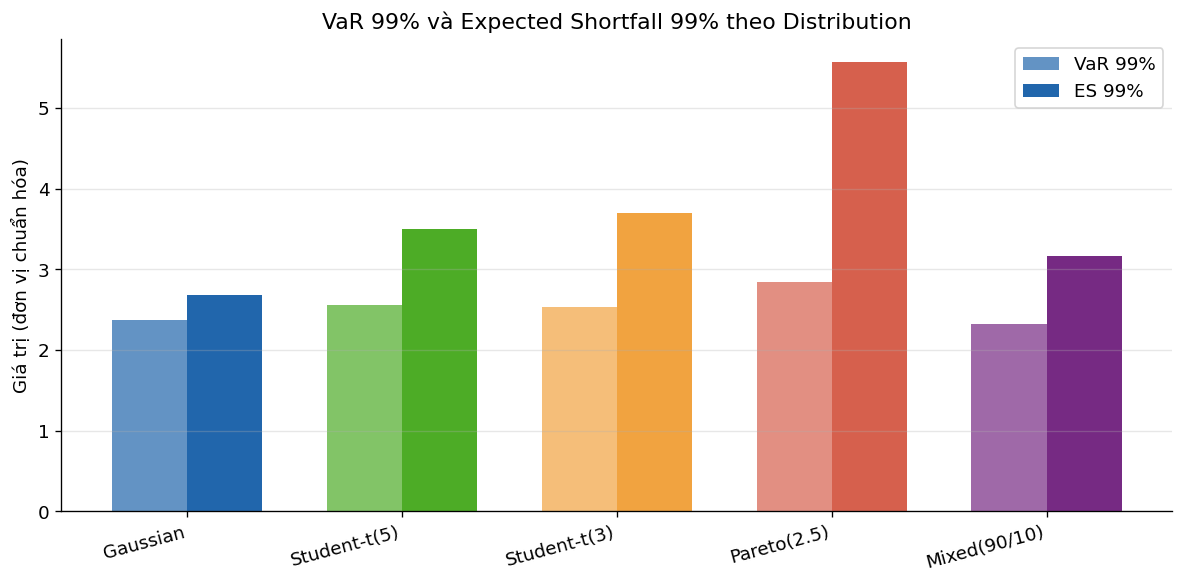

In [9]:
# Trực quan hóa VaR và ES tại confidence level 99%
fig, ax = plt.subplots(figsize=(10, 5))

names = list(datasets.keys())
var99 = [tail_quantile(datasets[n], 0.01, tail="right") for n in names]
es99  = [tail_conditional_expectation(datasets[n], 0.99, tail="right") for n in names]

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, var99, width, label="VaR 99%",
               color=[COLORS[n] for n in names], alpha=0.7)
bars2 = ax.bar(x + width/2, es99,  width, label="ES 99%",
               color=[COLORS[n] for n in names], alpha=1.0)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylabel("Giá trị (đơn vị chuẩn hóa)")
ax.set_title("VaR 99% và Expected Shortfall 99% theo Distribution")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
### Insights from VaR vs ES (99%)

Biểu đồ so sánh **VaR 99%** và **ES 99%** cho thấy rõ mức độ **tail risk** giữa các distribution.

---

#### Gaussian: baseline ổn định

- VaR ≈ 2.38
- ES ≈ 2.69

→ khoảng cách nhỏ

Insight:

> Tail mỏng → khi vượt VaR thì thiệt hại không tăng nhiều

---

#### Student-t: tail dày hơn rõ rệt

##### Student-t(5):
- VaR ≈ 2.56
- ES ≈ 3.49

##### Student-t(3):
- VaR ≈ 2.53
- ES ≈ 3.70

→ ES tăng mạnh so với VaR

Insight:

> Heavy tail không làm VaR tăng nhiều, nhưng làm ES tăng đáng kể

---

#### Pareto: extreme tail risk

- VaR ≈ 2.84
- ES ≈ 5.57

→ ES gần gấp đôi VaR

Insight:

> Power-law tail tạo ra extreme events rất lớn
> VaR gần như “bỏ sót” phần rủi ro này

---

#### Mixed (90/10): rủi ro bị che giấu

- VaR ≈ 2.32 (gần Gaussian)
- ES ≈ 3.16 (cao hơn rõ rệt)

Insight:

> Distribution trông “an toàn” theo VaR nhưng vẫn chứa tail risk lớn

---

### So sánh trực quan

| Distribution | VaR | ES | Nhận xét |
|-------------|-----|----|----------|
| Gaussian | thấp | gần VaR | ổn định |
| Student-t | trung bình | cao hơn | heavy tail |
| Pareto | không quá lớn | rất cao | extreme risk |
| Mixed | giống Gaussian | cao hơn | hidden risk |

---

### Insight quan trọng

Khoảng cách giữa ES và VaR:

$$
\text{Gap} = \text{ES} - \text{VaR}
$$

phản ánh trực tiếp độ dày của tail:

- Gap nhỏ → light tail
- Gap lớn → heavy tail

---

### Kết luận

- Gaussian: rủi ro dễ kiểm soát
- Student-t: tail bắt đầu nguy hiểm
- Pareto: tail chi phối hoàn toàn
- Mixed: rủi ro ẩn khó phát hiện

> ES là metric cần thiết để đánh giá đúng tail risk, đặc biệt trong dữ liệu heavy-tail

---

---
## 5. Deviation from Gaussian — Tổng hợp

Phần này tổng hợp tất cả dấu hiệu **heavy-tail** vào một **heatmap** tương đối để dễ so sánh. Mỗi chỉ số được chuẩn hóa theo giá trị của **Gaussian** để thấy mức độ lệch của từng **distribution**.

In [10]:
# Tổng hợp các chỉ số tương đối so với Gaussian
gauss = datasets["Gaussian"]
gauss_es99  = tail_conditional_expectation(gauss, 0.99, tail="right")
gauss_var99 = tail_quantile(gauss, 0.01, tail="right")
gauss_kurt  = float(stats.kurtosis(gauss, fisher=True))
gauss_max   = float(gauss.max())

summary_rows = []
for name, arr in datasets.items():
    kurt   = float(stats.kurtosis(arr, fisher=True))
    var99  = tail_quantile(arr, 0.01, tail="right")
    es99   = tail_conditional_expectation(arr, 0.99, tail="right")
    maxval = float(arr.max())
    summary_rows.append({
        "Distribution":        name,
        "Kurtosis (abs)":      round(kurt, 2),
        "VaR99 / VaR99_Gauss": round(var99 / gauss_var99, 2),
        "ES99  / ES99_Gauss":  round(es99  / gauss_es99,  2),
        "Max   / Max_Gauss":   round(maxval / gauss_max,  2),
    })

df_summary = pd.DataFrame(summary_rows).set_index("Distribution")
df_summary.style.background_gradient(cmap="YlOrRd", axis=0)

,Kurtosis (abs),VaR99 / VaR99_Gauss,ES99 / ES99_Gauss,Max / Max_Gauss
Distribution,,,,
Gaussian,0.040000,1.000000,1.000000,1.000000
Student-t(5),4.330000,1.080000,1.300000,2.440000
Student-t(3),7.510000,1.070000,1.380000,2.320000
Pareto(2.5),75.480000,1.200000,2.070000,3.680000
Mixed(90/10),5.800000,0.980000,1.180000,3.340000


### 5.1 Ý nghĩa các chỉ số

Các metric đều được chuẩn hóa theo Gaussian (= 1):

- **Kurtosis (abs)**: đo tail thickness tổng thể
- **VaR99 / VaR\_Gauss**: so sánh threshold extreme
- **ES99 / ES\_Gauss**: so sánh tail severity
- **Max / Max\_Gauss**: extreme thực tế trong sample

---

### 5.2 Gaussian: baseline

- Tất cả ≈ 1
→ làm chuẩn để so sánh

---

### 5.3 Student-t: tail dày nhưng “ổn định”

#### Student-t(5):
- Kurtosis ≈ 4.33
- VaR ≈ 1.08
- ES ≈ 1.30
- Max ≈ 2.44

#### Student-t(3):
- Kurtosis ≈ 7.51
- VaR ≈ 1.07
- ES ≈ 1.38
- Max ≈ 2.32

Insight:

> Tail dày rõ rệt (kurtosis cao), nhưng VaR tăng ít → ES phản ánh rõ hơn

---

### 5.4 Pareto: tail chi phối hoàn toàn

- Kurtosis ≈ 75.48
- VaR ≈ 1.20
- ES ≈ 2.07
- Max ≈ 3.68

Insight:

> VaR chỉ tăng nhẹ nhưng ES và Max tăng mạnh
→ extreme risk nằm sâu trong tail

---

### 5.5 Mixed: rủi ro bị “ẩn”

- Kurtosis ≈ 5.80
- VaR ≈ 0.98 (gần Gaussian)
- ES ≈ 1.18
- Max ≈ 3.34

Insight:

> VaR không phát hiện được risk
> nhưng ES và Max cho thấy tail bất thường

---

### 5.6 Insight quan trọng

So sánh các metric:

- Kurtosis → phát hiện tail dày
- VaR → gần như “không nhạy” với heavy tail
- ES → phản ánh tốt tail risk
- Max → extreme thực tế (nhưng noisy)

---

### 5.7 Kết luận tổng hợp

- Gaussian → baseline ổn định
- Student-t → heavy tail tăng dần
- Pareto → tail cực đoan, power-law
- Mixed → nguy hiểm vì “trông bình thường”

Insight cốt lõi:

> Heavy tail không thể đánh giá chỉ bằng VaR hoặc mean/variance
> cần kết hợp ES và các tail diagnostics

---

**Heatmap** cho thấy rõ phổ **tail heaviness**: từ **Gaussian** (baseline = 1.0 hoặc 0 cho kurtosis) đến **Pareto** và **Student-t(3)** với các chỉ số cao hơn nhiều lần. **ES99** nhạy hơn **VaR99** với **heavy tail** — đây là lý do **ES** được ưu tiên hơn **VaR** trong đánh giá **tail risk** thực tế.

---
## 6. Summary

Trong notebook này, chúng ta đã phân tích toàn diện các tính chất thống kê của năm **dataset** và xác định dấu hiệu **heavy-tail** thông qua nhiều góc nhìn bổ sung:

---

### 6.1 Tổng hợp kết quả

1. **Moment diagnostics**
   **Excess kurtosis** tăng rõ rệt theo mức độ **tail heaviness**:
   - Gaussian ≈ 0
   - Student-t tăng dần khi df giảm
   - Pareto rất lớn

   → cung cấp tín hiệu ban đầu về tail nhưng chưa đủ để kết luận.

---

2. **Normality tests**
   Tất cả các distribution có **heavy tail** đều bị bác bỏ giả thuyết:

   $$
   H_0: X \sim \mathcal{N}(\mu, \sigma^2)
   $$

   → kể cả **Mixed(90/10)** với chỉ 10% thành phần heavy-tail.

   → cho thấy normality test rất nhạy với tail deviation.

---

3. **Log-log survival plot (CCDF)**
   - Pareto: đường thẳng → **power-law tail**
   - Student-t: gần thẳng ở tail → **heavy tail nhưng không thuần power-law**
   - Gaussian: cong mạnh → **light tail**

   → phân biệt rõ bản chất decay của tail.

---

4. **Mean Excess Function (MEF)**

   $$
   e(u) = \mathbb{E}[X - u \mid X > u]
   $$

   - Gaussian: giảm
   - Student-t: tăng nhẹ
   - Pareto: tăng tuyến tính

   → cho thấy cách tail “mở rộng” khi threshold tăng.

---

5. **Hill plot**

   - Pareto: plateau rõ → ước lượng $\alpha$ ổn định
   - Student-t: plateau yếu → heavy tail nhưng không thuần
   - Mixed: không ổn định → không phải power-law

   → xác nhận lại kết quả từ CCDF.

---

6. **Tail risk metrics (VaR, ES)**

   - VaR tăng nhẹ giữa các distribution
   - ES tăng mạnh với heavy-tail

   → đặc biệt với Pareto và Mixed:

   $$
   \text{ES} \gg \text{VaR}
   $$

   → cho thấy VaR không đủ để đo tail risk.

---

### 6.2 Insight cốt lõi

- **Heavy tail không thể phát hiện bằng mean/variance**
- **VaR đánh giá thấp rủi ro extreme**
- **ES là metric quan trọng nhất cho tail risk**
- **Heavy tail ≠ power-law (Student-t là ví dụ điển hình)**
- **Mixture có thể che giấu rủi ro nghiêm trọng**

---

### 6.3 Kết luận

Không có một phương pháp đơn lẻ nào đủ để phân tích tail:

- Moment → tín hiệu ban đầu
- Test → xác nhận deviation
- CCDF / Hill → bản chất tail
- MEF → dynamics của tail
- ES → impact thực tế

→ cần kết hợp để có cái nhìn đầy đủ về **extreme risk**

---

### 6.4 Next step

**03_distribution_modeling.ipynb**

- Fit các **parametric model**:
  - Normal
  - Student-t
  - Stable

- Đánh giá:
  - **AIC / BIC**
  - **Goodness-of-fit**
  - Khả năng nắm bắt **tail behavior**

---